In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
pd.set_option('display.max_columns', None)

In [117]:
df=pd.read_csv('/content/gurgaon_properties_missing_value_imputation.csv')

In [118]:
df.duplicated().sum()

np.int64(129)

In [119]:
# delete the duplicate row
df.drop_duplicates(inplace=True)

In [120]:
df

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,bestech park view aindependentda,sector 81,4.35,7937.0,4,4,3,2.0,Relatively New,5480.0,0,1,1,0,0,0,51
1,flat,signature global solera,sector 107,0.28,5680.0,2,2,2,6.0,Relatively New,543.0,0,0,0,0,0,0,45
2,flat,hcbs sports ville,sohna road,0.29,5588.0,2,2,1,4.0,Relatively New,577.0,0,0,0,0,0,0,44
3,flat,orchid petals,sector 49,2.55,12319.0,3,4,3,8.0,Relatively New,2060.0,1,0,0,0,0,1,49
4,house,signature global city,sector 37d,1.27,8089.0,3,3,3,4.0,Under Construction,1570.0,0,0,0,1,0,0,89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,house,sector 14 rwa,sector 14,5.51,16990.0,3,3,2,4.0,Moderately Old,3249.0,0,0,0,0,0,0,14
3683,flat,microtek greenburg,sector 86,1.23,8311.0,2,2,3,13.0,Relatively New,1339.0,1,0,0,0,0,0,6
3684,flat,imperia the esfera,sector 37c,0.87,5513.0,2,3,3+,5.0,Relatively New,1300.0,1,0,0,0,0,0,109
3685,flat,ambience creacions,sector 22,1.65,11957.0,2,2,2,9.0,Relatively New,1200.0,0,0,0,1,1,2,133


In [121]:
df.shape

(3558, 18)

In [122]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [123]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sector 81,4.35,4,4,3,2.0,Relatively New,5480.0,0,1,1,0,0,0,51
1,flat,sector 107,0.28,2,2,2,6.0,Relatively New,543.0,0,0,0,0,0,0,45
2,flat,sohna road,0.29,2,2,1,4.0,Relatively New,577.0,0,0,0,0,0,0,44
3,flat,sector 49,2.55,3,4,3,8.0,Relatively New,2060.0,1,0,0,0,0,1,49
4,house,sector 37d,1.27,3,3,3,4.0,Under Construction,1570.0,0,0,0,1,0,0,89


luxury score

<Axes: xlabel='luxury_score'>

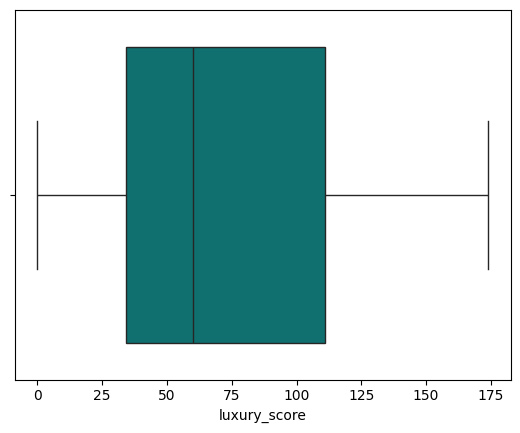

In [124]:
sns.boxplot(x=df['luxury_score'],color='teal')

In [125]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [126]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [127]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,house,sector 81,4.35,4,4,3,2.0,Relatively New,5480.0,0,1,1,0,0,0,51,Medium
1,flat,sector 107,0.28,2,2,2,6.0,Relatively New,543.0,0,0,0,0,0,0,45,Low
2,flat,sohna road,0.29,2,2,1,4.0,Relatively New,577.0,0,0,0,0,0,0,44,Low
3,flat,sector 49,2.55,3,4,3,8.0,Relatively New,2060.0,1,0,0,0,0,1,49,Low
4,house,sector 37d,1.27,3,3,3,4.0,Under Construction,1570.0,0,0,0,1,0,0,89,Medium


floorNum

<Axes: xlabel='floorNum'>

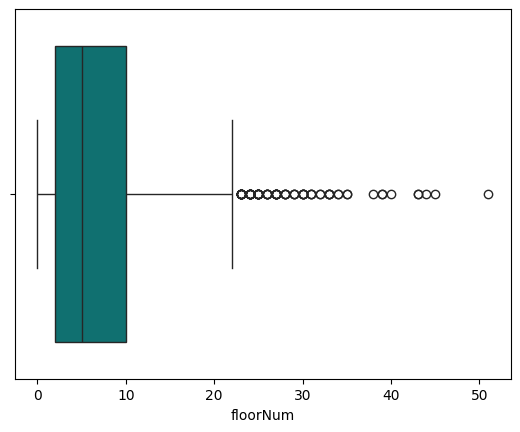

In [128]:
sns.boxplot(x=df['floorNum'],color='teal')

In [129]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [130]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [131]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,house,sector 81,4.35,4,4,3,2.0,Relatively New,5480.0,0,1,1,0,0,0,51,Medium,Low Floor
1,flat,sector 107,0.28,2,2,2,6.0,Relatively New,543.0,0,0,0,0,0,0,45,Low,Mid Floor
2,flat,sohna road,0.29,2,2,1,4.0,Relatively New,577.0,0,0,0,0,0,0,44,Low,Mid Floor
3,flat,sector 49,2.55,3,4,3,8.0,Relatively New,2060.0,1,0,0,0,0,1,49,Low,Mid Floor
4,house,sector 37d,1.27,3,3,3,4.0,Under Construction,1570.0,0,0,0,1,0,0,89,Medium,Mid Floor


In [132]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [133]:
train_df

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,house,sector 81,4.35,4,4,3,Relatively New,5480.0,0,1,1,0,0,0,Medium,Low Floor
1,flat,sector 107,0.28,2,2,2,Relatively New,543.0,0,0,0,0,0,0,Low,Mid Floor
2,flat,sohna road,0.29,2,2,1,Relatively New,577.0,0,0,0,0,0,0,Low,Mid Floor
3,flat,sector 49,2.55,3,4,3,Relatively New,2060.0,1,0,0,0,0,1,Low,Mid Floor
4,house,sector 37d,1.27,3,3,3,Under Construction,1570.0,0,0,0,1,0,0,Medium,Mid Floor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,house,sector 14,5.51,3,3,2,Moderately Old,3249.0,0,0,0,0,0,0,Low,Mid Floor
3683,flat,sector 86,1.23,2,2,3,Relatively New,1339.0,1,0,0,0,0,0,Low,High Floor
3684,flat,sector 37c,0.87,2,3,3+,Relatively New,1300.0,1,0,0,0,0,0,Medium,Mid Floor
3685,flat,sector 22,1.65,2,2,2,Relatively New,1200.0,0,0,0,1,1,2,Medium,Mid Floor


In [134]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [135]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,92.0,4,4,3.0,3.0,5480.0,0,1,1,0,0,0,2.0,1.0
1,0.0,9.0,2,2,2.0,3.0,543.0,0,0,0,0,0,0,1.0,2.0
2,0.0,111.0,2,2,1.0,3.0,577.0,0,0,0,0,0,0,1.0,2.0
3,0.0,55.0,3,4,3.0,3.0,2060.0,1,0,0,0,0,1,1.0,2.0
4,1.0,44.0,3,3,3.0,4.0,1570.0,0,0,0,1,0,0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,1.0,20.0,3,3,2.0,0.0,3249.0,0,0,0,0,0,0,1.0,2.0
3683,0.0,98.0,2,2,3.0,3.0,1339.0,1,0,0,0,0,0,1.0,0.0
3684,0.0,43.0,2,3,4.0,3.0,1300.0,1,0,0,0,0,0,2.0,2.0
3685,0.0,27.0,2,2,2.0,3.0,1200.0,0,0,0,1,1,2,2.0,2.0


In [136]:
y_label

,price
0,4.35
1,0.28
2,0.29
3,2.55
4,1.27
...,...
3682,5.51
3683,1.23
3684,0.87
3685,1.65


Technique 1 - Correlation Analysis

<Axes: >

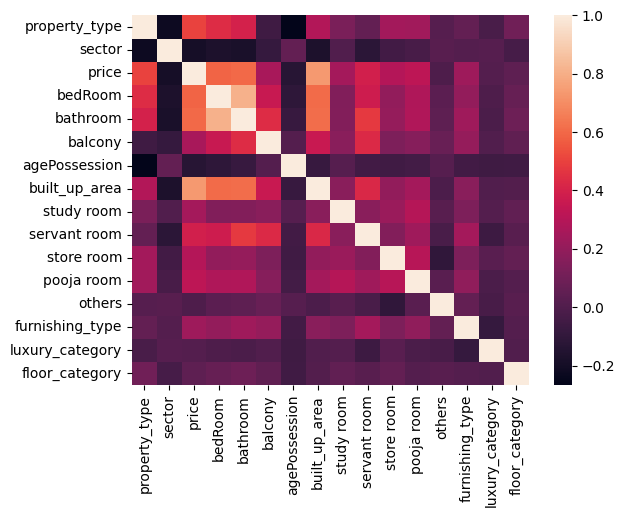

In [137]:
sns.heatmap(data_label_encoded.corr())

In [138]:
fi_df1 = (
    data_label_encoded
    .corr(numeric_only=True)['price']
    .drop('price')
    .to_frame(name='corr_coeff')
    .reset_index()
    .rename(columns={'index': 'feature'})
)

fi_df1

,feature,corr_coeff
0,property_type,0.504798
1,sector,-0.197516
2,bedRoom,0.585453
3,bathroom,0.602475
4,balcony,0.262485
5,agePossession,-0.135374
6,built_up_area,0.737011
7,study room,0.251235
8,servant room,0.390506
9,store room,0.296806


Technique 2 - Random Forest Feature Importance

In [139]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.639453
1,sector,0.111168
0,property_type,0.097979
2,bedRoom,0.026136
3,bathroom,0.024666
8,servant room,0.020671
5,agePossession,0.015073
4,balcony,0.013833
12,furnishing_type,0.012230
13,luxury_category,0.008400


Technique 3 - Gradient Boosting Feature importances

In [140]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.685559
0,property_type,0.101997
1,sector,0.101909
2,bedRoom,0.032811
3,bathroom,0.030725
8,servant room,0.023167
9,store room,0.008216
7,study room,0.003751
12,furnishing_type,0.003541
5,agePossession,0.003239


Technique 4 - Permutation Importance

In [141]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.732758
0,property_type,0.197288
1,sector,0.133619
3,bathroom,0.012810
8,servant room,0.011275
4,balcony,0.008528
2,bedRoom,0.006803
7,study room,0.002513
14,floor_category,0.001698
5,agePossession,0.001396



Technique 5 - LASSO

In [142]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.516229
0,property_type,0.751436
3,bathroom,0.271144
7,study room,0.197847
12,furnishing_type,0.182722
8,servant room,0.177812
9,store room,0.177212
10,pooja room,0.087395
13,luxury_category,0.067332
2,bedRoom,0.017258



Technique 6 - RFE

In [143]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.644150
1,sector,0.102321
0,property_type,0.100071
2,bedRoom,0.029069
3,bathroom,0.023327
8,servant room,0.021645
5,agePossession,0.014465
4,balcony,0.013187
12,furnishing_type,0.010943
7,study room,0.010304


Technique 7 - Linear Regression Weights

In [144]:
from sklearn.linear_model import LinearRegression
# Train a linear regression model on the label-encoded and standardized training data
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.518720
0,property_type,0.750889
3,bathroom,0.278027
7,study room,0.205896
12,furnishing_type,0.192130
8,servant room,0.186841
9,store room,0.181721
10,pooja room,0.090367
13,luxury_category,0.078679
2,bedRoom,0.019938


Technique 8 - SHAP

In [145]:
!pip install shap

In [146]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[ 6.96917918e-01, -1.72227131e+00, -2.78120401e-01, ...,
        -1.27050776e-01,  1.29507719e-02,  2.07959818e-03],
       [-1.79713629e-01, -1.78672082e-01, -6.43241371e-02, ...,
        -1.24627455e-02, -6.70438451e-03, -1.00291570e-02],
       [-1.85361948e-01, -3.97511159e-01, -4.76162266e-02, ...,
        -1.32389192e-02, -4.57848420e-03, -3.57248521e-03],
       ...,
       [-2.84087028e-01, -1.44297497e-01, -1.30372993e-01, ...,
        -1.78174248e-02, -3.38472157e-03, -1.99313092e-03],
       [-1.74495105e-01,  2.65809656e-01, -4.96442828e-02, ...,
         2.57876616e-01,  1.15468907e-02, -1.94177281e-04],
       [-5.50824730e-01, -4.08391433e-01, -7.84182108e-03, ...,
        -2.23026493e-02, -3.66373793e-02, -2.45934535e-02]])

In [147]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.268957
0,property_type,0.491337
1,sector,0.396617
3,bathroom,0.120881
8,servant room,0.102066
2,bedRoom,0.061207
4,balcony,0.039063
12,furnishing_type,0.033205
5,agePossession,0.027639
14,floor_category,0.024175


In [148]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [149]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
property_type,0.504798,0.097979,0.101997,0.197288,0.751436,0.100071,0.750889,0.491337
sector,-0.197516,0.111168,0.101909,0.133619,-0.051378,0.102321,-0.060498,0.396617
bedRoom,0.585453,0.026136,0.032811,0.006803,0.017258,0.029069,0.019938,0.061207
bathroom,0.602475,0.024666,0.030725,0.012810,0.271144,0.023327,0.278027,0.120881
balcony,0.262485,0.013833,0.001660,0.008528,-0.057428,0.013187,-0.080300,0.039063
agePossession,-0.135374,0.015073,0.003239,0.001396,-0.000000,0.014465,-0.000124,0.027639
built_up_area,0.737011,0.639453,0.685559,0.732758,1.516229,0.644150,1.518720,1.268957
study room,0.251235,0.008007,0.003751,0.002513,0.197847,0.010304,0.205896,0.018886
servant room,0.390506,0.020671,0.023167,0.011275,0.177812,0.021645,0.186841,0.102066


In [150]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [151]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

,0
feature,
built_up_area,0.623448
property_type,0.133178
sector,0.117474
bathroom,0.027239
bedRoom,0.023482
servant room,0.022887
balcony,0.010250
agePossession,0.008905
furnishing_type,0.007146


In [152]:
# to drop pooja room, store room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,92.0,4,4,3.0,3.0,5480.0,0,1,1,0,0,0,2.0,1.0
1,0.0,9.0,2,2,2.0,3.0,543.0,0,0,0,0,0,0,1.0,2.0
2,0.0,111.0,2,2,1.0,3.0,577.0,0,0,0,0,0,0,1.0,2.0
3,0.0,55.0,3,4,3.0,3.0,2060.0,1,0,0,0,0,1,1.0,2.0
4,1.0,44.0,3,3,3.0,4.0,1570.0,0,0,0,1,0,0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,1.0,20.0,3,3,2.0,0.0,3249.0,0,0,0,0,0,0,1.0,2.0
3683,0.0,98.0,2,2,3.0,3.0,1339.0,1,0,0,0,0,0,1.0,0.0
3684,0.0,43.0,2,3,4.0,3.0,1300.0,1,0,0,0,0,0,2.0,2.0
3685,0.0,27.0,2,2,2.0,3.0,1200.0,0,0,0,1,1,2,2.0,2.0


In [153]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [154]:
scores.mean()

np.float64(0.7933914395859842)

In [155]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room','store room' ,'others']), y_label, cv=5, scoring='r2')

In [156]:
scores.mean()

np.float64(0.7960824354217089)

In [157]:
export_df = X_label.drop(columns=['pooja room','store room', 'others'])
export_df['price'] = y_label

In [160]:
export_df.to_csv('gurgaon_properties_post_feature_selection__1.csv', index=False)

In [159]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,furnishing_type,luxury_category,floor_category,price
0,1.0,92.0,4,4,3.0,3.0,5480.0,0,1,0,2.0,1.0,4.35
1,0.0,9.0,2,2,2.0,3.0,543.0,0,0,0,1.0,2.0,0.28
2,0.0,111.0,2,2,1.0,3.0,577.0,0,0,0,1.0,2.0,0.29
3,0.0,55.0,3,4,3.0,3.0,2060.0,1,0,1,1.0,2.0,2.55
4,1.0,44.0,3,3,3.0,4.0,1570.0,0,0,0,2.0,2.0,1.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,1.0,20.0,3,3,2.0,0.0,3249.0,0,0,0,1.0,2.0,5.51
3683,0.0,98.0,2,2,3.0,3.0,1339.0,1,0,0,1.0,0.0,1.23
3684,0.0,43.0,2,3,4.0,3.0,1300.0,1,0,0,2.0,2.0,0.87
3685,0.0,27.0,2,2,2.0,3.0,1200.0,0,0,2,2.0,2.0,1.65
